### 1. Import bibliotek
W tym miejscu importujemy biblioteki, które będą nam potrzebne do analizy danych. Jeżeli w tym miejscu widoczny będzie błąd, to konieczne jest zainstalowanie biblioteki w danym środowisku. W takim wypadku wchodzimy w terminal, aktywujemy środowisko pracy, instalujemy biblioteki (pip install X).

In [ ]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns
# tych bibliotek używamy do wizualizacji naszych danych

import plotly.express as px
# użyjemy jej do interaktywnego podlgądu danych

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
# przyda nam się do stworzenia zbioru treningowego oraz testowego oraz zaimportowania modelu regresji

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# wykorzystamy do przedstawienia informacji składających się na jakość naszego modelu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/My Drive/Data')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Przygotowanie danych do analizy
Wykorzystamy zbiór danych "Titanic - Machine Learning from Disaster". Więcej informacji o tych danych można znaleźć na stronie internetowej - https://www.kaggle.com/c/titanic/data Co właściwie będziemy robić? Wykorzystamy model regresji logistycznej do przewidzenia, która zmienna ma największe znaczenie w oszacowaniu czy dana osoba przeżyje katastrofę.

In [ ]:
train = pd.read_csv("DSP_6.csv")
# na tym etapie tworzymy nową zmienną, którą nazywamy train, zawierającą nasz zbiór danych
# tym razem nazywamy naszą bazę danych jako train, ale możemy równie dobrze określić je jako df

In [ ]:
train.head()
# pclass to klasa pasażerów
# sibsp to liczba rodzeństwa lub małżonków
# parch to liczba rodziców / dzieci
# embarked to port zaokrętowania (C = Cherbourg, Q = Queenstown, S = Southampton)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### 2.1. Brakujące dane
Możemy wygenerować mapę ciepła symbolizującą braki danych - każdy "pomarańczowy pasek" to miejsce, w którym jest brak danych

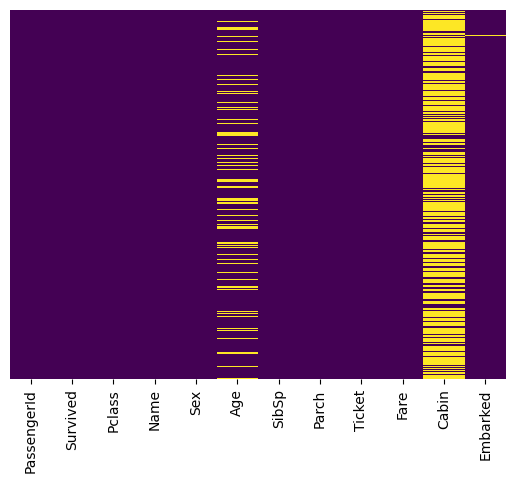

In [ ]:
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis');
# cbar ustalamy jako false, ponieważ nie wniesie nam to dodatkowych informacji

Już po tej prostej wizualizacji widzimy, że mamy dużo przypadków brakujących danych odnoszących się do wieku oraz kabiny. Brakujące dane odnośnie wieku możemy zastąpić średnią (jak na poprzednich zajęciach), natomiast w przypadku informacji odnoszącej się do kabiny taki zabieg nie byłby już poprawny (mamy za dużo takich przypadków). Usuniemy zatem zmienną odnoszącą się do kabiny.

In [ ]:
train.isnull().any()
# to kod z poprzednich zajęć - sprawdzamy czy mamy jakiekolwiek brakujące dane

,0
PassengerId,False
Survived,False
Pclass,False
Name,False
Sex,False
Age,True
SibSp,False
Parch,False
Ticket,False
Fare,False


In [ ]:
(train.loc[:, train.isnull().any()].isna().sum().sort_values(ascending=False) / len(train) * 100).round(2)

,0
Cabin,77.10
Age,19.87
Embarked,0.22


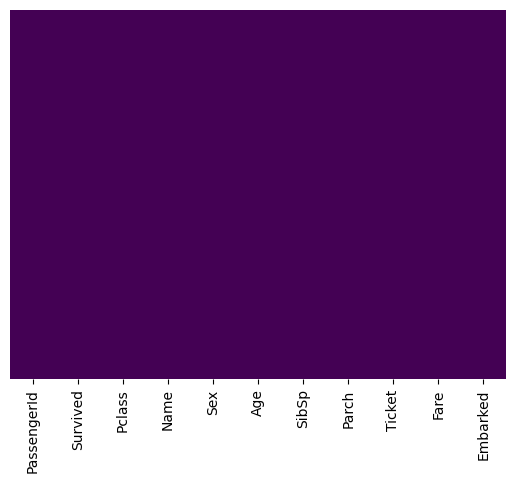

In [ ]:
train.drop(columns=['Cabin'], inplace=True)
# w kroku pierwszym pozbywamy się zmiennej "cabin"
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
train['Age'] = train['Age'].fillna(train['Age'].median())
# w kroku drugim wypełniamy brakujące wartości dominantą / medianą
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis');

Mamy potwierdzenie, że nasz zbiór danych nie zawiera już brakujących wartości.

Uzupełnianie medianą, zależną od grupy (np. według płci i klasy kabiny).

In [ ]:
#train['Age'] = train['Age'].fillna(train.groupby(['Sex', 'Pclass'])['Age'].transform('median'))

#### 2.2. Eksploracja danych
Poniżej znajduje się kilka sposobów na przedstawienie wykresów do naszych danych.

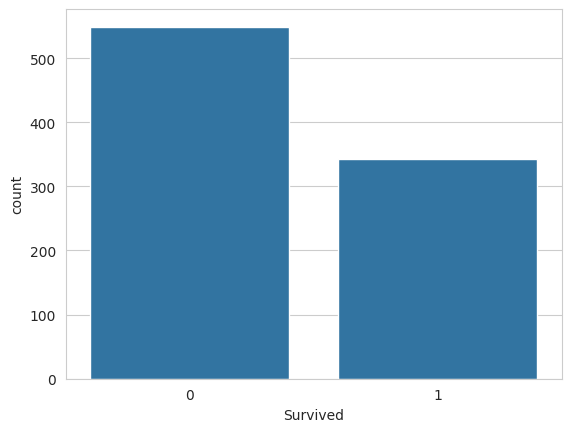

In [ ]:
sns.set_style('whitegrid')
sns.countplot(train, x='Survived');
# używamy biblioteki seaborn do stworzenia prostego wykresu symbolizującego osoby, które przeżyły (1) i nie przeżyły (0)

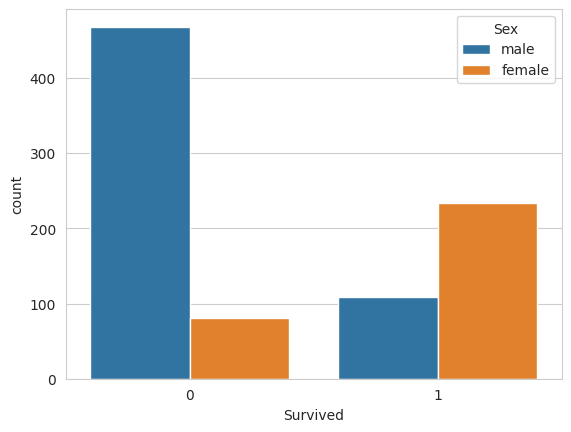

In [ ]:
sns.countplot(train, x='Survived', hue='Sex');
# możemy też wygenerować taki wykres, który powie nam więcej o płci osób, które nie przeżyły

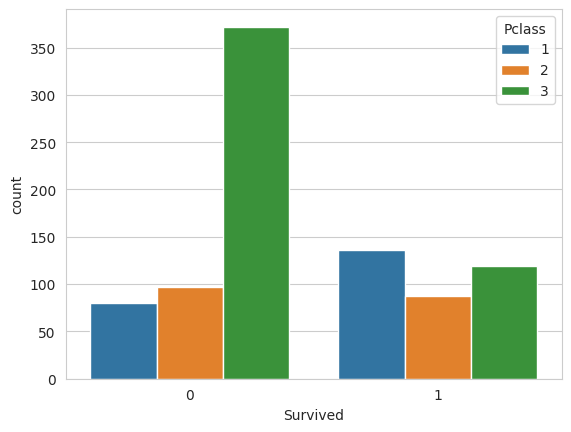

In [ ]:
sns.countplot(train, x='Survived', hue='Pclass', palette='tab10');

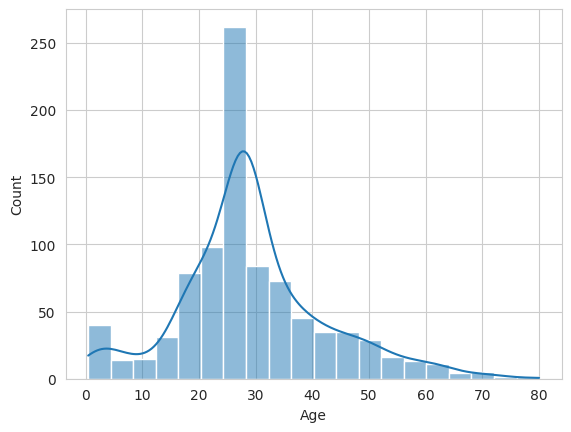

In [ ]:
sns.histplot(train['Age'], kde=True, bins=20);

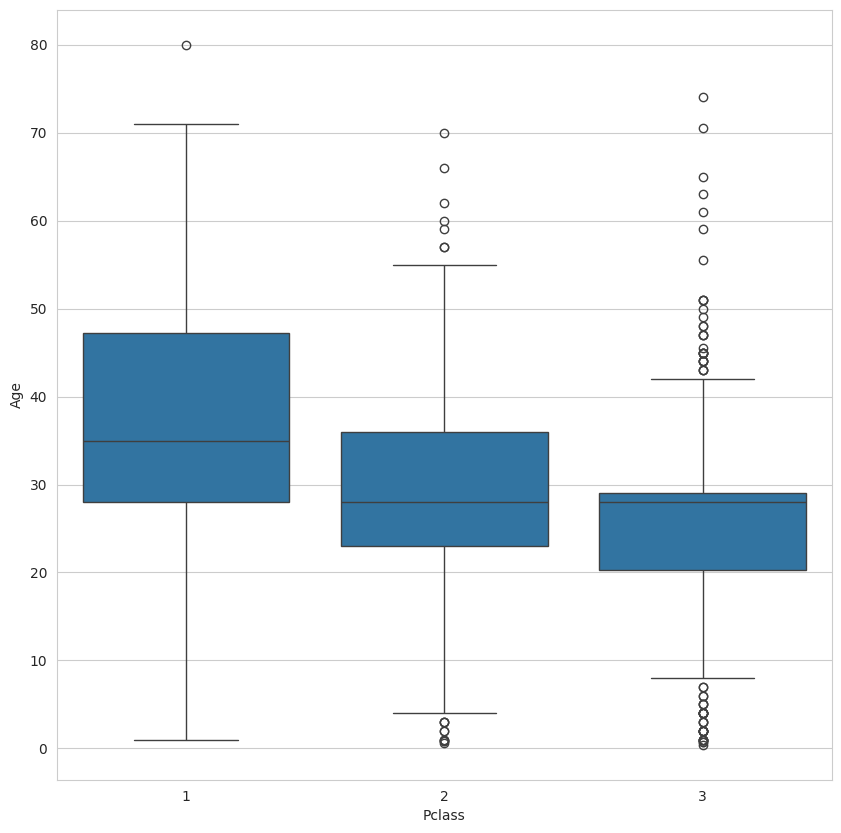

In [ ]:
plt.figure(figsize=(10, 10))
sns.boxplot(train, x='Pclass', y='Age');
# wygenerujemy sobie boxplot, czyli wykres skrzynkowy dla wieku oraz klasy pasażerów

In [ ]:
px.histogram(train, x='Age', nbins=20, color_discrete_sequence=['green']).show()

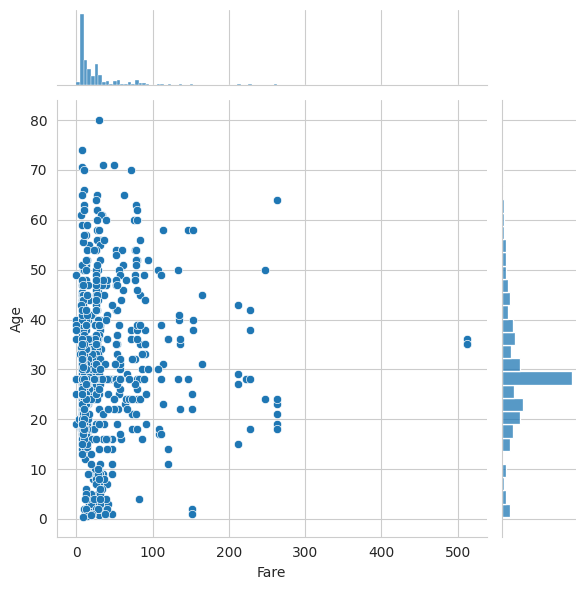

In [ ]:
sns.jointplot(train, x='Fare', y='Age');

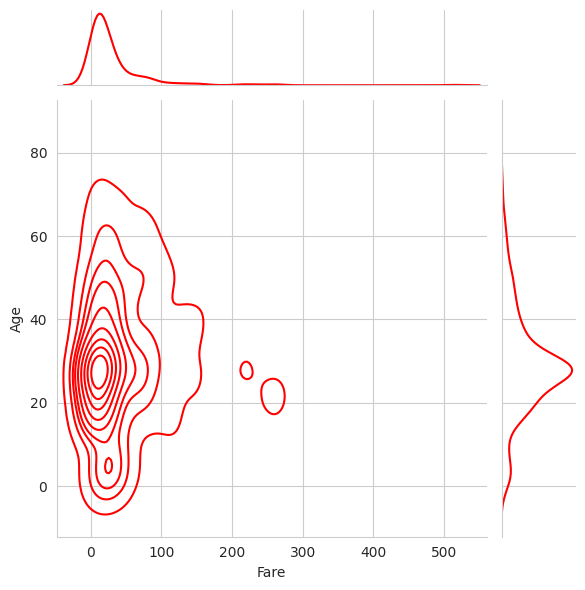

In [ ]:
sns.jointplot(train, x='Fare', y='Age', kind='kde', color='red');

#### 2.3. Konwersja zmiennych do modelu regresji
Zanim przejdziemy dalej musimy jeszcze zadbać o właściwe nazewnictwo zmiennych. W naszej bazie danych mamy na razie informację w postaci Stringów - np. płeć jest oznaczona jako male lub female. Musimy to naprawić za pomocą "dumy variable". Zamienimy je sobie na wartości np. 0 będzie dla mężczyzn i 1 dla kobiet. Przczytaj o tym więcej w tym miejscu - https://pl.wikipedia.org/wiki/Dummy_coding

In [ ]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [ ]:
sex = pd.get_dummies(train['Sex'], dtype='int', drop_first=True)
embarked = pd.get_dummies(train['Embarked'], dtype='int', drop_first=True)

In [ ]:
sex

,male
0,1
1,0
2,0
3,0
4,1
...,...
886,1
887,0
888,0
889,1


In [ ]:
embarked

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1
...,...,...
886,0,1
887,0,1
888,0,1
889,0,0


In [ ]:
train_enc = pd.get_dummies(train, columns=['Sex', 'Embarked'], dtype='int', drop_first=True)
train_enc.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,0,1


In [ ]:
train_enc.drop(columns=['Name','Ticket', 'PassengerId'], inplace=True)
# te kolumny już nam nie są dłużej potrzebne - przerobiliśmy je na 'dummy variables' a niektóre nie dodają nowych informacji

### 3. Regresja logistyczna

In [ ]:
X = train_enc.drop('Survived', axis=1)
y = train_enc['Survived']
# najpierw określamy zmienną, którą będziemy chcieli przewidzieć

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
# test size odnosi się do liczby obserwacji przeznaczonej do wytrenowania modelu

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((801, 8), (90, 8), (801,), (90,))

In [ ]:
logmodel = LogisticRegression(max_iter = 1000)
logmodel.fit(X_train, y_train)
predictions = logmodel.predict(X_test)
# na tym etapie mamy już wytrenowany model

In [ ]:
print(classification_report(y_test, predictions))
# uzyskujemy informację o precyzji, recall, f1, etc.
# te wszystkie dane przydadzą się nam do oceny naszego modelu

              precision    recall  f1-score   support

           0       0.82      0.84      0.83        55
           1       0.74      0.71      0.72        35

    accuracy                           0.79        90
   macro avg       0.78      0.78      0.78        90
weighted avg       0.79      0.79      0.79        90



In [ ]:
confusion_matrix(y_test, predictions)

array([[46,  9],
       [10, 25]])

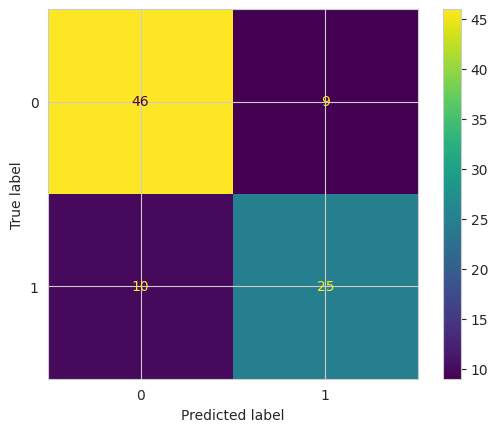

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, predictions);

# Zadania PD - SUML_2

### Zad. 1
Dodaj kilka kolejnych wykresów w celu dalszej eksploracji danych.

Stwórz np. wykresy, pokazujące informację dotyczącą liczby członków rodziny na pokładzie, czy też opłaty, która została uiszczona przez pasażerów - spróbuj uzależnić wyświetlane informacje od tego, czy pasażer przeżył katastrofę statku.

Z uwagi na to, że dane te zawierają przypadki odstające, zmień jego wielkość za pomocą parametru figsize​

In [ ]:
titanic_df = pd.read_csv("DSP_6.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


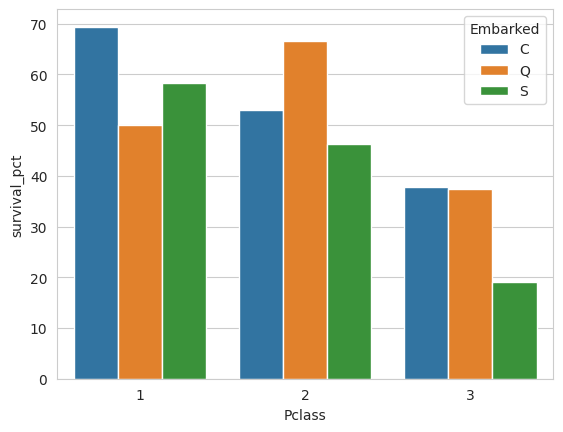

In [ ]:
survival = (
  titanic_df
  .groupby(["Embarked", "Pclass"])["Survived"]
  .mean()
  .mul(100)
  .reset_index()
  .rename(columns={"Survived": "survival_pct"})
)
sns.barplot(data=survival, hue='Embarked', y='survival_pct', x='Pclass');

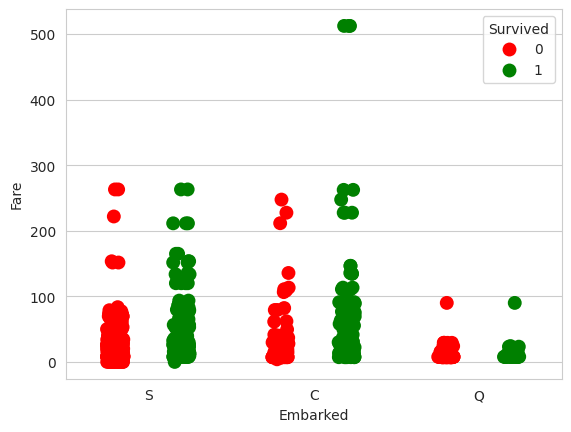

In [ ]:
sns.stripplot(
    data=titanic_df,
    x="Embarked", y="Fare",
    hue="Survived",
    dodge=True,
    palette={0: "Red", 1: "Green"},
    size=10
);

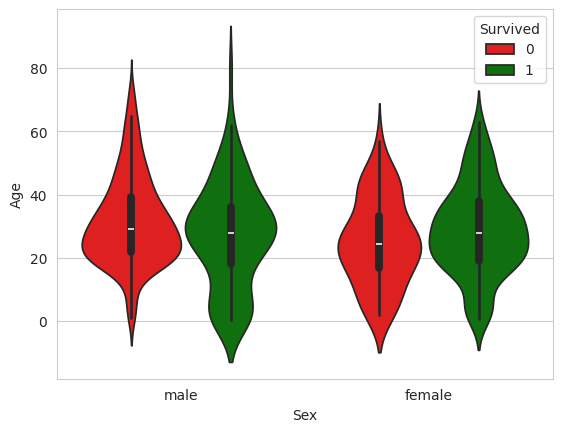

In [ ]:
sns.violinplot(y="Age", x="Sex",hue='Survived' ,data=titanic_df, palette={0: "Red", 1: "Green"});

## Zad 2.
Spróbuj wytrenować nowy model regresji logistycznej dla tych samych danych.
Tym razem nie dokonuj uzupełniania wartości brakujących, czy transformacji zmiennych (po prostu załaduj ramkę danych i spróbuj ją zastosować do modelu).
Jaki błąd otrzymujesz?

In [ ]:
X = titanic_df.drop('Survived', axis=1)
y = titanic_df['Survived']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 11), (179, 11), (712,), (179,))

In [ ]:
logmodel = LogisticRegression(max_iter = 1000)
logmodel.fit(X_train, y_train)
predictions = logmodel.predict(X_test)

ValueError: could not convert string to float: 'Lam, Mr. Ali'

In [ ]:
# ValueError: could not convert string to float: 'Lam, Mr. Ali'
# ValueError: could not convert string to float: 'male'

## Zad 3.

Załaduj ponownie dane, tym razem poprawnie, ale wytrenuj kilka modeli modyfikując:
wybrane hiperparametry (test_size​, random_state​ lub max_iter​),
sposób uzupełnienia wartości brakujących w kolumnie Age​ (uzależniając go od płci, klasy kabiny itp.),
obsługę wartości odstających, poprzez ich przycięcie (użyj metody clip​ z pakietu pandas) na podstawie reguły 1.5*IQR.

Zaobserwuj, jak powyższe modyfikacje wpłynęły na zmiany w parametrach modelu lub jego metrykach oceny.

In [ ]:
def fill_age_smart(df, smart=True):
    df = df.copy()

    if smart:
      df['Age'] = df.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
    else:
      df['Age'] = df['Age'].fillna(df['Age'].median())

    return df

In [ ]:
def clip_df(df, columns):
    df = df.copy()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=lower, upper=upper)
    return df

In [ ]:
from dataclasses import dataclass
@dataclass
class Scenario:
    name: str
    fill_age_smart: bool = False
    clip: bool = False
    test_size: float = 0.1
    random_state: int = 42
    max_iter: int = 500

In [ ]:
def prepare_and_train(scenario: Scenario):
    df = pd.read_csv("DSP_6.csv")
    df.drop(columns=['Name', 'Ticket', 'PassengerId', 'Cabin'], inplace=True)

    df = fill_age_smart(df, scenario.fill_age_smart)

    if scenario.clip:
        df = clip_df(df, ['Age', 'Fare'])

    df = pd.get_dummies(df, columns=['Sex', 'Embarked'], dtype='int', drop_first=True)

    df.dropna(inplace=True)

    X = df.drop('Survived', axis=1)
    y = df['Survived']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=scenario.test_size,
        random_state=scenario.random_state,
        stratify=y)

    model = LogisticRegression(max_iter=scenario.max_iter, random_state=scenario.random_state)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    #do ROG-AUC
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "scenario": scenario.name,
        "y_test":   y_test,
        "y_prob":   y_prob,
        "report":   classification_report(y_test, y_pred, target_names=["RIP", "Alive"],output_dict=True)
    }


In [ ]:
scenarios = [
    Scenario(name="Baseline"),
    Scenario(name="Slightly Smart", fill_age_smart=True),
    Scenario(name="Only Clip", clip=True),
    Scenario(name="Smarter", fill_age_smart=True, clip=True),
    Scenario(name="Baseline+", test_size=0.2, max_iter=1000),
    Scenario(name="Smart++", fill_age_smart=True, clip=True, test_size=0.2, max_iter=1000),
    Scenario(name="Ultimate", fill_age_smart=True, clip=True, test_size=0.4, max_iter=10000)
]


In [ ]:
from sklearn.metrics import roc_auc_score
results = []

for scenario in scenarios:
    results.append(prepare_and_train(scenario));


In [ ]:
rows = []

for result in results:
    r = result["report"]
    rows.append({
        "Scenario": result["scenario"],
        "ROC-AUC":          round(roc_auc_score(result["y_test"], result["y_prob"]), 4),
        "F1-0": round(r["RIP"]["f1-score"], 4),
        "F1-1": round(r["Alive"]["f1-score"], 4),
        "Accuracy": round(r["accuracy"], 4),
        "F1 macro": round(r["macro avg"]["f1-score"], 4),
        "F1 weighted": round(r["weighted avg"]["f1-score"], 4),
        "Precision macro": round(r["macro avg"]["precision"], 4),
        "Recall macro": round(r["macro avg"]["recall"], 4),
    })

comparison_df = pd.DataFrame(rows).set_index("Scenario")
comparison_df

,ROC-AUC,F1-0,F1-1,Accuracy,F1 macro,F1 weighted,Precision macro,Recall macro
Scenario,,,,,,,,
Baseline,0.8478,0.8288,0.7246,0.7889,0.7767,0.7883,0.7784,0.7753
Slightly Smart,0.8494,0.8496,0.7463,0.8111,0.7979,0.8094,0.8044,0.7935
Only Clip,0.8478,0.8288,0.7246,0.7889,0.7767,0.7883,0.7784,0.7753
Smarter,0.8509,0.8496,0.7463,0.8111,0.7979,0.8094,0.8044,0.7935
Baseline+,0.8444,0.8485,0.7244,0.8045,0.7864,0.8007,0.8015,0.7788
Smart++,0.8414,0.8559,0.7442,0.8156,0.8000,0.8128,0.8118,0.7933
Ultimate,0.8541,0.8609,0.7586,0.8235,0.8098,0.8217,0.8176,0.8045


## Zad. 4
Załaduj nowy zbiór danych DSP_2.csv​. Wytrenuj nowy model regresji logistycznej w celu określenia, czy u danej osoby wystąpi choroba serca (zmienna HeartDisease​). Do wytrenowania modelu użyj wszystkich pozostałych zmiennych, które występują w tym zbiorze danych. Czy model cechuje się zadowalającymi metrykami? Jeżeli tak, to dlaczego? Czy i jak mógłby zostać wykorzystany w praktyce?

In [ ]:
hd_df = pd.read_csv("DSP_2.csv")
hd_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


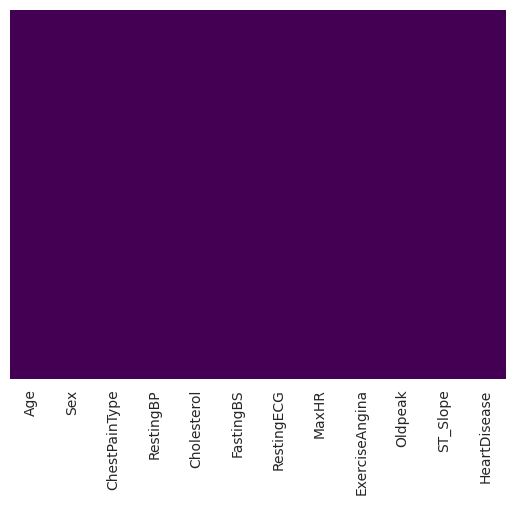

In [ ]:
sns.heatmap(hd_df.isnull(), yticklabels=False, cbar=False, cmap='viridis');

In [ ]:
unique_values_df = pd.DataFrame([
    {"column": col, "unique_values": sorted(hd_df[col].unique().tolist()), "count": len(hd_df[col].unique().tolist())}
    for col in hd_df.columns
])
unique_values_df

,column,unique_values,count
0,Age,"[28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 3...",50
1,Sex,"[F, M]",2
2,ChestPainType,"[ASY, ATA, NAP, TA]",4
3,RestingBP,"[0, 80, 92, 94, 95, 96, 98, 100, 101, 102, 104...",67
4,Cholesterol,"[0, 85, 100, 110, 113, 117, 123, 126, 129, 131...",222
5,FastingBS,"[0, 1]",2
6,RestingECG,"[LVH, Normal, ST]",3
7,MaxHR,"[60, 63, 67, 69, 70, 71, 72, 73, 77, 78, 80, 8...",119
8,ExerciseAngina,"[N, Y]",2
9,Oldpeak,"[-2.6, -2.0, -1.5, -1.1, -1.0, -0.9, -0.8, -0....",53


In [ ]:
hd_df = pd.get_dummies(hd_df, columns=['Sex', 'ChestPainType','RestingECG','ExerciseAngina','ST_Slope'], dtype='int', drop_first=True)

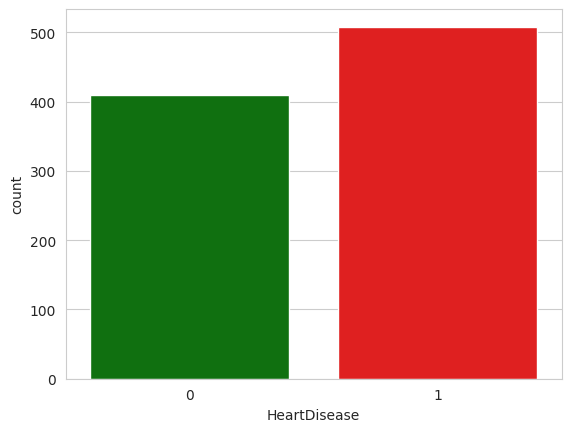

In [ ]:
sns.countplot(
    data=hd_df,
    x="HeartDisease",
    hue="HeartDisease",
    palette=["green", "red"],
    legend=False,
);

In [ ]:
X = hd_df.drop('HeartDisease', axis=1)
y = hd_df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=73,
    stratify=y)

model = LogisticRegression(max_iter=5000, random_state=73)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#do ROG-AUC
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

result_hd = {
    "scenario": 'Heart Deasises',
    "y_test":   y_test,
    "y_prob":   y_prob,
    "report":   classification_report(y_test, y_pred, target_names=["RIP", "Alive"],output_dict=True)
}



In [ ]:
rows_hd = []


r = result_hd["report"]
rows_hd.append({
  "Scenario": result_hd["scenario"],
  "ROC-AUC":          round(roc_auc_score(result_hd["y_test"], result_hd["y_prob"]), 4),
  "F1-0": round(r["RIP"]["f1-score"], 4),
  "F1-1": round(r["Alive"]["f1-score"], 4),
  "Accuracy": round(r["accuracy"], 4),
  "F1 macro": round(r["macro avg"]["f1-score"], 4),
  "F1 weighted": round(r["weighted avg"]["f1-score"], 4),
  "Precision macro": round(r["macro avg"]["precision"], 4),
  "Recall macro": round(r["macro avg"]["recall"], 4),
})

comparison_df_hd = pd.DataFrame(rows_hd).set_index("Scenario")
comparison_df_hd

,ROC-AUC,F1-0,F1-1,Accuracy,F1 macro,F1 weighted,Precision macro,Recall macro
Scenario,,,,,,,,
Heart Deasises,0.9369,0.8589,0.8878,0.875,0.8734,0.8749,0.8738,0.8729


Komentarz:
*Model w 93.7% przypadków poprawnie rankuje pacjenta chorego wyżej niż zdrowego.F1-1 (0.888) wyższe niż F1-0 (0.859), co oznacza, że model jest nieco lepszy w wykrywaniu chorych niż zdrowych, co jest pożądane. Dane nie wymagały oczyszczenia i było wiele cech silnie związanych z chorobami serca, np. Chest Pain i Max HR. Model mógłby służyć do ustalenia priorytetów w kolejce do specjalisty - potencjalnie chorzy mogliby liczyć na wizytę szybciej.*